In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy

from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
df_injured = pd.read_csv("heridos_limpio.csv")

/tmp/ipykernel_14900/1279655590.py:1: DtypeWarning: Columns (0: case_id_pkey, 1: juris) have mixed types. Specify dtype option on import or set low_memory=False.
  df_injured = pd.read_csv("heridos_limpio.csv")


In [3]:
df_injured.info()

<class 'pandas.DataFrame'>
RangeIndex: 64512 entries, 0 to 64511
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   unique_id                64512 non-null  int64  
 1   cnn_intrsctn_fkey        64512 non-null  float64
 2   cnn_sgmt_fkey            28793 non-null  float64
 3   case_id_pkey             64512 non-null  object 
 4   collision_date           64512 non-null  str    
 5   collision_time           64512 non-null  str    
 6   accident_year            64512 non-null  int64  
 7   month                    64512 non-null  str    
 8   day_of_week              64512 non-null  str    
 9   juris                    64512 non-null  object 
 10  primary_rd               64512 non-null  str    
 11  distance                 64512 non-null  float64
 12  direction                64512 non-null  str    
 13  weather_1                64512 non-null  str    
 14  collision_severity       64512 no

In [4]:
risk_cols = ['cnn_intrsctn_fkey', 'day_of_week', 'type_of_collision', 'mviw', 'ped_action', 'number_killed', 'number_injured']
df_injured.loc[:, risk_cols].info()

<class 'pandas.DataFrame'>
RangeIndex: 64512 entries, 0 to 64511
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   cnn_intrsctn_fkey  64512 non-null  float64
 1   day_of_week        64512 non-null  str    
 2   type_of_collision  64512 non-null  str    
 3   mviw               64512 non-null  str    
 4   ped_action         64512 non-null  str    
 5   number_killed      64512 non-null  float64
 6   number_injured     64512 non-null  int64  
dtypes: float64(2), int64(1), str(4)
memory usage: 3.4 MB


## 3. Carga y limpieza del histórico PCI

Cargamos las columnas del histórico PCI que describen el estado de la carretera
o intersección.

La columna `PCI_Change_Date` se convierte explícitamente a tipo fecha para poder
ordenar correctamente el histórico por CNN y quedarnos después con el registro
más reciente.

In [5]:
pci_cols = ["CNN", "PCI_Score", "Previous_PCI", "PCI_Change", "PCI_Change_Date", "Functional_Class"]

df_pci = pd.read_csv(
    "../PCI_Historico/CSVS/PCI-histo-cleaned-2005.csv",
    usecols=pci_cols,
    low_memory=False,
)

df_pci["CNN"] = pd.to_numeric(df_pci["CNN"], errors="coerce").astype("Int64")

df_pci["PCI_Change_Date"] = pd.to_datetime(
    df_pci["PCI_Change_Date"], errors="coerce"
)

for col in [
    "PCI_Score",
    "Previous_PCI",
    "PCI_Change",
]:
    df_pci[col] = pd.to_numeric(df_pci[col], errors="coerce")

df_pci.info()
df_pci.head()

<class 'pandas.DataFrame'>
RangeIndex: 203268 entries, 0 to 203267
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   CNN               203268 non-null  Int64         
 1   PCI_Score         203268 non-null  float64       
 2   Previous_PCI      203268 non-null  float64       
 3   PCI_Change        203268 non-null  float64       
 4   PCI_Change_Date   203268 non-null  datetime64[us]
 5   Functional_Class  203268 non-null  str           
dtypes: Int64(1), datetime64[us](1), float64(3), str(1)
memory usage: 9.5 MB


,CNN,PCI_Score,Previous_PCI,PCI_Change,PCI_Change_Date,Functional_Class
0,100000,100.0,100.0,0.0,2005-11-16 16:50:05,Arterial
1,100000,100.0,100.0,0.0,2007-07-26 16:21:27,Arterial
2,100000,93.0,100.0,-7.0,2009-08-10 15:43:09,Arterial
3,100000,73.0,93.0,-20.0,2010-12-23 13:37:35,Arterial
4,100000,56.0,73.0,-17.0,2013-01-08 15:18:02,Arterial


## 4. Reducción del histórico PCI a un único registro por CNN

El dataset PCI es histórico, por lo que un mismo CNN puede aparecer muchas veces.
Para poder enlazarlo con los accidentes a nivel de carretera/intersección,
reducimos el histórico a un único registro por CNN.

En este prototipo nos quedamos con el registro más reciente disponible para cada
CNN.

In [6]:
df_pci_latest = (
    df_pci.sort_values(["CNN", "PCI_Change_Date"], na_position="first")
    .drop_duplicates(subset="CNN", keep="last")
    .reset_index(drop=True)
)

print(f"Filas históricas PCI: {len(df_pci):,}")
print(f"CNN únicos tras reducir el histórico: {len(df_pci_latest):,}")

df_pci_latest.head()

Filas históricas PCI: 203,268
CNN únicos tras reducir el histórico: 18,179


,CNN,PCI_Score,Previous_PCI,PCI_Change,PCI_Change_Date,Functional_Class
0,100000,72.0,76.0,-4.0,2025-08-17 08:20:20,Arterial
1,101000,61.0,68.0,-7.0,2025-08-17 08:20:20,Arterial
2,102000,76.0,71.0,5.0,2025-08-17 08:20:20,Arterial
3,103000,75.0,74.0,1.0,2025-08-17 08:20:20,Arterial
4,104001,77.0,74.0,3.0,2025-08-17 08:20:21,Arterial


## 5. Separación entre intersecciones y segmentos

Para enlazar correctamente los accidentes con el PCI, distinguimos dos tipos de
CNN:

- intersecciones, que enlazan con `cnn_intrsctn_fkey`,
- segmentos, que enlazan con `cnn_sgmt_fkey`.

De esta forma evitamos mezclar claves de naturaleza distinta.

In [7]:
pci_intersection = (
    df_pci_latest.query("Functional_Class == 'Intersection'")
    .rename(columns={"CNN": "cnn_intrsctn_fkey"})
    .copy()
)

pci_segment = (
    df_pci_latest.query("Functional_Class != 'Intersection'")
    .rename(columns={"CNN": "cnn_sgmt_fkey"})
    .copy()
)

print(f"Intersecciones PCI: {len(pci_intersection):,}")
print(f"Segmentos PCI:      {len(pci_segment):,}")

Intersecciones PCI: 2,555
Segmentos PCI:      15,624


## 6. Comprobación de cobertura del merge

Antes de unir los datasets, comprobamos cuántos accidentes tienen una clave CNN
que aparece en el PCI ya reducido. Esta comprobación se hace sobre CNN únicos del
PCI y no sobre todo el histórico, para que el resultado sea interpretable.

In [8]:
match_intr = df_injured["cnn_intrsctn_fkey"].isin(
    pci_intersection["cnn_intrsctn_fkey"]
).sum()

match_sgmt = df_injured["cnn_sgmt_fkey"].isin(
    pci_segment["cnn_sgmt_fkey"]
).sum()

print(f"Accidentes con posible match por intersección: {match_intr:,}")
print(f"Accidentes con posible match por segmento:     {match_sgmt:,}")

Accidentes con posible match por intersección: 17,300
Accidentes con posible match por segmento:     26,298


## 7. Unión de accidentes con carretera, priorizando intersección

Un mismo accidente puede venir identificado por CNN de intersección o por CNN de
segmento. Para no duplicar registros, seguimos una regla sencilla:

1. primero intentamos enlazar por `cnn_intrsctn_fkey`,
2. si no hay match, intentamos enlazar por `cnn_sgmt_fkey`.

Además, conservamos las variables del PCI que luego podrán servir como entrada
del modelo, como el estado del pavimento, la clase funcional y la localización.

In [10]:
road_cols = [
    "PCI_Score",
    "Previous_PCI",
    "PCI_Change",
    "Functional_Class",
]

df_match_int = (
    df_injured.merge(
        pci_intersection[["cnn_intrsctn_fkey"] + road_cols],
        on="cnn_intrsctn_fkey",
        how="inner",
    )
    .rename(columns={"cnn_intrsctn_fkey": "CNN"})
    .drop(columns=["cnn_sgmt_fkey"])
    .assign(match_source="intersection")
)

matched_ids = set(df_match_int["unique_id"])

df_injured_rest = df_injured.loc[
    ~df_injured["unique_id"].isin(matched_ids)
].copy()

df_match_seg = (
    df_injured_rest.dropna(subset=["cnn_sgmt_fkey"])
    .merge(
        pci_segment[["cnn_sgmt_fkey"] + road_cols],
        on="cnn_sgmt_fkey",
        how="inner",
    )
    .rename(columns={"cnn_sgmt_fkey": "CNN"})
    .drop(columns=["cnn_intrsctn_fkey"])
    .assign(match_source="segment")
)

df_accidents_matched = pd.concat(
    [df_match_int, df_match_seg],
    ignore_index=True,
)

print(f"Accidentes enlazados por intersección: {len(df_match_int):,}")
print(f"Accidentes enlazados por segmento:     {len(df_match_seg):,}")
print(f"Total accidentes enlazados:            {len(df_accidents_matched):,}")
print(
    f"CNN con al menos un accidente:         "
    f"{df_accidents_matched['CNN'].nunique():,}"
)

df_accidents_matched.head()

Accidentes enlazados por intersección: 17,300
Accidentes enlazados por segmento:     19,061
Total accidentes enlazados:            36,361
CNN con al menos un accidente:         7,030


,unique_id,CNN,case_id_pkey,collision_date,collision_time,accident_year,month,day_of_week,juris,primary_rd,...,party2_type,party2_dir_of_travel,party2_move_pre_acc,point,supervisor_district,PCI_Score,Previous_PCI,PCI_Change,Functional_Class,match_source
0,29564,26514000.0,5333233,2011 September 11,10:30:00,2011,September,Sunday,3801,GEARY ST,...,Not Stated,Not Stated,Not Stated,POINT (-122.427613868 37.784908958),2.0,100.0,100.0,0.0,Intersection,intersection
1,92630,24236000.0,230808034,2023 November 13,20:45:00,2023,November,Monday,3801,12TH ST,...,Driver,North,Backing,POINT (-122.41374961 37.770347345),6.0,100.0,100.0,0.0,Intersection,intersection
2,125099,24293000.0,250203890,2025 April 11,13:54:00,2025,April,Friday,3801,06TH ST,...,Not Stated,Not Stated,Not Stated,POINT (-122.408708674 37.780971183),6.0,100.0,100.0,0.0,Intersection,intersection
3,45312,27855000.0,160546635,2016 July 07,13:32:00,2016,July,Thursday,3801,32ND AVE,...,Parked Vehicle,South,Parked,POINT (-122.492383746 37.78179476),1.0,100.0,100.0,0.0,Intersection,intersection
4,24660,30739000.0,140414206,2014 May 17,21:40:00,2014,May,Saturday,3801,MARKET ST,...,Not Stated,Not Stated,Not Stated,POINT (-122.407978595 37.784007606),6.0,100.0,100.0,0.0,Intersection,intersection


## 8. Agregación de accidentes por CNN

Una vez enlazados los accidentes con su carretera o intersección, agregamos la
información a nivel de CNN.

Este paso genera una tabla de resumen por carretera/intersección con variables
como:

- número de accidentes,
- número total de heridos,
- número total de fallecidos,
- frecuencia de accidentes fatales,
- categorías más frecuentes del accidente.

Importante: estas variables agregadas sirven para análisis descriptivo, pero no
todas deben usarse como entrada del modelo si queremos predecir accidentes a
partir solo de características de la carretera.

In [11]:
def mode_or_na(s):
    s = s.dropna()
    if s.empty:
        return pd.NA
    return s.mode().iloc[0]


df_accident_aggs = (
    df_accidents_matched.groupby("CNN")
    .agg(
        accident_count=("unique_id", "nunique"),
        row_count=("unique_id", "size"),
        total_injured=("number_injured", "sum"),
        total_killed=("number_killed", "sum"),
        avg_injured=("number_injured", "mean"),
        fatal_accidents=("number_killed", lambda s: (s > 0).sum()),
        top_day_of_week=("day_of_week", mode_or_na),
        top_collision=("type_of_collision", mode_or_na),
        top_mviw=("mviw", mode_or_na),
        top_ped_action=("ped_action", mode_or_na),
    )
    .reset_index()
)

df_accident_aggs.head()

,CNN,accident_count,row_count,total_injured,total_killed,avg_injured,fatal_accidents,top_day_of_week,top_collision,top_mviw,top_ped_action
0,100000.0,6,6,6,0.0,1.00,0,Tuesday,Vehicle/Pedestrian,Pedestrian,No Pedestrian Involved
1,101000.0,6,6,9,0.0,1.50,0,Monday,Broadside,Other Motor Vehicle,No Pedestrian Involved
2,102000.0,4,4,7,0.0,1.75,0,Monday,Rear End,Other Motor Vehicle,Crossing Not in Crosswalk
3,103000.0,2,2,5,0.0,2.50,0,Monday,Sideswipe,Not Stated,"In Road, Including Shoulder"
4,104001.0,3,3,3,0.0,1.00,0,Monday,Vehicle/Pedestrian,Pedestrian,Crossing in Crosswalk at Intersection


## 9. Construcción del dataset final de modelado

Para predecir número de accidentes por CNN necesitamos incluir también las
carreteras o intersecciones que no han tenido accidentes.

Por eso el dataset final de modelado se construye partiendo del PCI reducido
(`df_pci_latest`) y haciendo un `left join` con los agregados de accidentes.

Los CNN sin accidentes reciben valor 0 en la variable objetivo.

In [12]:
df_model = df_pci_latest.merge(df_accident_aggs, on="CNN", how="left").copy()

for col in [
    "accident_count",
    "row_count",
    "total_injured",
    "total_killed",
    "avg_injured",
    "fatal_accidents",
]:
    df_model[col] = df_model[col].fillna(0)

for col in [
    "top_day_of_week",
    "top_collision",
    "top_mviw",
    "top_ped_action",
]:
    df_model[col] = df_model[col].fillna("Sin_accidentes")

df_model["accident_count"] = df_model["accident_count"].astype(int)
df_model["row_count"] = df_model["row_count"].astype(int)
df_model["total_injured"] = df_model["total_injured"].astype(int)
df_model["total_killed"] = df_model["total_killed"].round().astype(int)
df_model["fatal_accidents"] = df_model["fatal_accidents"].astype(int)

print(f"Carreteras/intersecciones totales: {len(df_model):,}")
print(
    f"Con al menos un accidente: "
    f"{(df_model['accident_count'] > 0).sum():,}"
)
print(
    f"Sin accidentes: "
    f"{(df_model['accident_count'] == 0).sum():,}"
)

df_model.head()

Carreteras/intersecciones totales: 18,179
Con al menos un accidente: 7,030
Sin accidentes: 11,149


,CNN,PCI_Score,Previous_PCI,PCI_Change,PCI_Change_Date,Functional_Class,accident_count,row_count,total_injured,total_killed,avg_injured,fatal_accidents,top_day_of_week,top_collision,top_mviw,top_ped_action
0,100000,72.0,76.0,-4.0,2025-08-17 08:20:20,Arterial,6,6,6,0,1.00,0,Tuesday,Vehicle/Pedestrian,Pedestrian,No Pedestrian Involved
1,101000,61.0,68.0,-7.0,2025-08-17 08:20:20,Arterial,6,6,9,0,1.50,0,Monday,Broadside,Other Motor Vehicle,No Pedestrian Involved
2,102000,76.0,71.0,5.0,2025-08-17 08:20:20,Arterial,4,4,7,0,1.75,0,Monday,Rear End,Other Motor Vehicle,Crossing Not in Crosswalk
3,103000,75.0,74.0,1.0,2025-08-17 08:20:20,Arterial,2,2,5,0,2.50,0,Monday,Sideswipe,Not Stated,"In Road, Including Shoulder"
4,104001,77.0,74.0,3.0,2025-08-17 08:20:21,Arterial,3,3,3,0,1.00,0,Monday,Vehicle/Pedestrian,Pedestrian,Crossing in Crosswalk at Intersection


In [13]:
df_model.to_csv("pci_heridos_modelo.csv", index=False)

## 12. Selección de variables y preprocesado

Definimos como variable objetivo el número de accidentes por CNN
(`accident_count`).

Como variables de entrada usamos únicamente atributos de la carretera o
intersección:

- PCI_Score
- Previous_PCI
- PCI_Change
- Functional_Class
- Latitude
- Longitude

Las variables numéricas se escalan con StandardScaler y la variable categórica
`Functional_Class` se transforma con one-hot encoding.

La división de datos se hace en tres subconjuntos:
- entrenamiento,
- validación,
- test.

Además, estratificamos según si el CNN tiene o no accidentes para conservar la
proporción de casos positivos.

count    18179.000000
mean         2.000165
std          5.979873
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        170.000000
Name: accident_count, dtype: float64

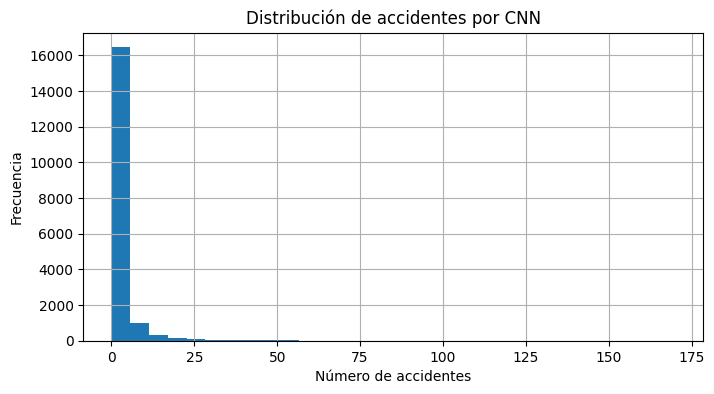

In [14]:
display(df_model["accident_count"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df_model["accident_count"], bins=30)
plt.title("Distribución de accidentes por CNN")
plt.xlabel("Número de accidentes")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

In [16]:
feature_cols = [
    "PCI_Score",
    "Previous_PCI",
    "PCI_Change",
    "Functional_Class",
]
target_col = "accident_count"

num_cols = [
    "PCI_Score",
    "Previous_PCI",
    "PCI_Change",
]
cat_cols = ["Functional_Class"]

X = df_model[feature_cols].copy()
y = df_model[target_col].astype(np.float32).to_numpy()

stratify_all = (y > 0).astype(int)

X_train_df, X_temp_df, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=stratify_all,
)

stratify_temp = (y_temp > 0).astype(int)

X_val_df, X_test_df, y_val, y_test = train_test_split(
    X_temp_df,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=stratify_temp,
)

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", ohe, cat_cols),
    ]
)

X_train = preprocessor.fit_transform(X_train_df).astype(np.float32)
X_val = preprocessor.transform(X_val_df).astype(np.float32)
X_test = preprocessor.transform(X_test_df).astype(np.float32)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

feature_names = preprocessor.get_feature_names_out()
print("Número de features tras el preprocesado:", len(feature_names))
print(feature_names)

Train: (12725, 8) (12725,)
Val:   (2727, 8) (2727,)
Test:  (2727, 8) (2727,)
Número de features tras el preprocesado: 8
['num__PCI_Score' 'num__Previous_PCI' 'num__PCI_Change'
 'cat__Functional_Class_Arterial' 'cat__Functional_Class_Collector'
 'cat__Functional_Class_Intersection' 'cat__Functional_Class_Other'
 'cat__Functional_Class_Residential']


## 13. Conversión a tensores y DataLoaders

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", device)

batch_size = 256

train_ds = TensorDataset(
    torch.from_numpy(X_train),
    torch.from_numpy(y_train.astype(np.float32)),
)
val_ds = TensorDataset(
    torch.from_numpy(X_val),
    torch.from_numpy(y_val.astype(np.float32)),
)
test_ds = TensorDataset(
    torch.from_numpy(X_test),
    torch.from_numpy(y_test.astype(np.float32)),
)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

Dispositivo: cpu


## 14. Definición de la red neuronal

In [18]:
class AccidentNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)


model = AccidentNet(input_dim=X_train.shape[1]).to(device)
criterion = nn.PoissonNLLLoss(log_input=True, full=False)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

model

AccidentNet(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

## 15. Funciones auxiliares para entrenamiento y evaluación

Definimos funciones para:

- evaluar la pérdida en entrenamiento/validación,
- obtener predicciones en escala de conteo,
- calcular métricas de error:
  - MAE,
  - RMSE.

La predicción final del modelo se interpreta como el número esperado de
accidentes por CNN.

In [19]:
def predict_from_log_rate(log_rate):
    log_rate = torch.clamp(log_rate, min=-10, max=10)
    return torch.exp(log_rate)


def evaluate_loader(model, loader, criterion, device):
    model.eval()

    total_loss = 0.0
    y_true_all = []
    y_pred_all = []

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            log_rate = model(xb)
            loss = criterion(log_rate, yb)

            total_loss += loss.item() * len(xb)

            y_pred = predict_from_log_rate(log_rate)

            y_true_all.append(yb.cpu().numpy())
            y_pred_all.append(y_pred.cpu().numpy())

    y_true = np.concatenate(y_true_all)
    y_pred = np.concatenate(y_pred_all)

    avg_loss = total_loss / len(loader.dataset)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return avg_loss, mae, rmse

## 16. Entrenamiento del modelo

Entrenamos la red durante varias épocas y monitorizamos la pérdida en el
conjunto de validación.

Aplicamos early stopping para detener el entrenamiento cuando la validación deja
de mejorar, evitando así sobreajuste.

In [20]:
epochs = 200
patience = 20

history = {
    "train_loss": [],
    "val_loss": [],
    "val_mae": [],
    "val_rmse": [],
}

best_val_loss = float("inf")
best_state = None
epochs_without_improvement = 0

for epoch in range(1, epochs + 1):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        log_rate = model(xb)
        loss = criterion(log_rate, yb)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * len(xb)

    train_loss = running_loss / len(train_loader.dataset)
    val_loss, val_mae, val_rmse = evaluate_loader(
        model,
        val_loader,
        criterion,
        device,
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)
    history["val_rmse"].append(val_rmse)

    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_mae={val_mae:.4f} | "
            f"val_rmse={val_rmse:.4f}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping en la época {epoch}.")
        break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 001 | train_loss=0.9069 | val_loss=0.3957 | val_mae=2.3903 | val_rmse=5.8752
Epoch 010 | train_loss=-0.6219 | val_loss=-0.7244 | val_mae=2.2188 | val_rmse=5.3828
Epoch 020 | train_loss=-0.6497 | val_loss=-0.7302 | val_mae=2.1781 | val_rmse=5.3840
Epoch 030 | train_loss=-0.6348 | val_loss=-0.7335 | val_mae=2.2115 | val_rmse=5.3825
Epoch 040 | train_loss=-0.6555 | val_loss=-0.7265 | val_mae=2.1649 | val_rmse=5.3848
Epoch 050 | train_loss=-0.6591 | val_loss=-0.7250 | val_mae=2.1573 | val_rmse=5.3895
Early stopping en la época 57.


## 17. Evolución del entrenamiento

Representamos la pérdida en entrenamiento y validación para comprobar si el
modelo converge y si aparece sobreajuste.

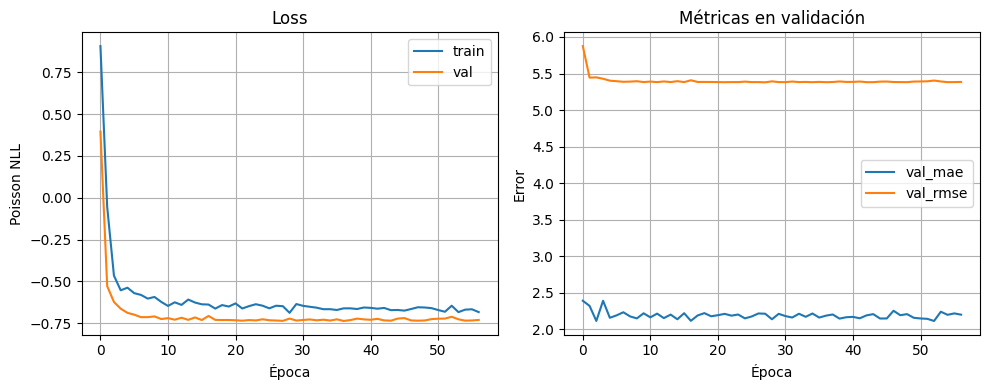

In [21]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history["train_loss"], label="train")
plt.plot(history["val_loss"], label="val")
plt.title("Loss")
plt.xlabel("Época")
plt.ylabel("Poisson NLL")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history["val_mae"], label="val_mae")
plt.plot(history["val_rmse"], label="val_rmse")
plt.title("Métricas en validación")
plt.xlabel("Época")
plt.ylabel("Error")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 18. Evaluación final en test

Una vez seleccionado el mejor modelo según validación, evaluamos su rendimiento
sobre el conjunto de test, que no ha sido utilizado durante el entrenamiento.

Las métricas se interpretan así:

- MAE: error absoluto medio en número de accidentes.
- RMSE: penaliza más los errores grandes.

In [22]:
test_loss, test_mae, test_rmse = evaluate_loader(
    model,
    test_loader,
    criterion,
    device,
)

print(f"Test loss: {test_loss:.4f}")
print(f"Test MAE:  {test_mae:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Test loss: -0.7995
Test MAE:  2.1581
Test RMSE: 5.7193


## 19. Uso del modelo para predecir accidentes

Definimos una función auxiliar que recibe un subconjunto de filas con columnas de
entrada y devuelve el número esperado de accidentes predicho por la red.

In [23]:
def predict_accident_count(df_rows, model, preprocessor, device):
    X_rows = preprocessor.transform(df_rows[feature_cols]).astype(np.float32)
    X_tensor = torch.from_numpy(X_rows).to(device)

    model.eval()
    with torch.no_grad():
        log_rate = model(X_tensor)
        preds = predict_from_log_rate(log_rate).cpu().numpy()

    out = df_rows[feature_cols].copy()
    out["pred_accident_count"] = preds
    out["pred_accident_count_round"] = np.rint(preds).astype(int)

    return out

sample_rows = df_model.sample(10, random_state=SEED)
predict_accident_count(sample_rows, model, preprocessor, device)

,PCI_Score,Previous_PCI,PCI_Change,Functional_Class,pred_accident_count,pred_accident_count_round
16607,100.0,100.0,0.0,Intersection,7.188426,7
1034,82.0,88.0,-6.0,Residential,0.358245,0
17215,100.0,100.0,0.0,Intersection,7.188426,7
10928,74.0,77.0,-3.0,Collector,2.010127,2
6301,76.0,79.0,-3.0,Residential,0.475931,0
6518,94.0,92.0,2.0,Residential,0.256686,0
7517,45.0,45.0,0.0,Other,2.272540,2
16631,100.0,100.0,0.0,Other,0.065616,0
12570,63.0,67.0,-4.0,Arterial,4.107849,4
960,64.0,67.0,-3.0,Residential,0.677372,1


## 20. Comparación de valores reales y predichos

Para inspeccionar visualmente el comportamiento del modelo, comparamos el número
real de accidentes con el número esperado predicho en un subconjunto del test.

In [24]:
def predict_array(X_array, model, device):
    X_tensor = torch.from_numpy(X_array.astype(np.float32)).to(device)

    model.eval()
    with torch.no_grad():
        log_rate = model(X_tensor)
        preds = predict_from_log_rate(log_rate).cpu().numpy()

    return preds


y_test_pred = predict_array(X_test, model, device)

comparison = pd.DataFrame(
    {
        "real": y_test,
        "predicho": y_test_pred,
        "predicho_redondeado": np.rint(y_test_pred).astype(int),
    }
)

comparison.head(20)

,real,predicho,predicho_redondeado
0,0.0,0.515432,1
1,79.0,7.188426,7
2,0.0,0.470917,0
3,2.0,1.995023,2
4,0.0,0.809766,1
5,0.0,0.343242,0
6,0.0,4.805111,5
7,0.0,0.298891,0
8,2.0,0.316501,0
9,0.0,0.560856,1


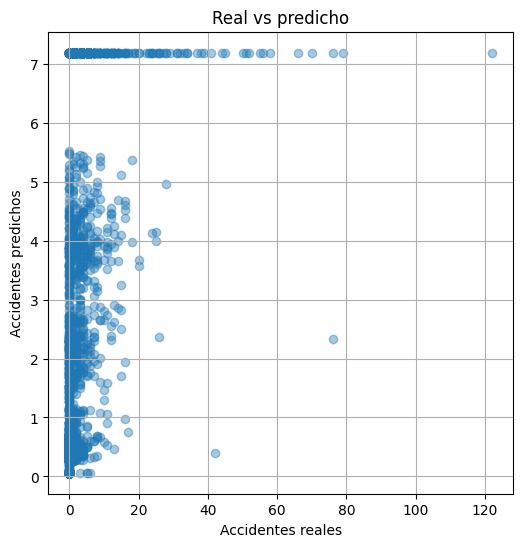

In [25]:
plt.figure(figsize=(6, 6))
plt.scatter(comparison["real"], comparison["predicho"], alpha=0.4)
plt.xlabel("Accidentes reales")
plt.ylabel("Accidentes predichos")
plt.title("Real vs predicho")
plt.grid(True)
plt.show()